Hey there! This is a minimal working example of using this package to compute the Onsager transport coefficients (and other properties that can be derived from them) for amorphous (or liquid-like) solids. 

In [1]:
from py_oats import OnsagerTransportAnalyzer, plot_correlation_pairwise, plot_all_correlations

To read an xdatcar file, which is the output of a VASP AIMD calculation:

In [2]:
file = 'Li2Ti3O7_1750.0K.XDATCAR'
analyzer = OnsagerTransportAnalyzer.from_xdatcar(file, temperature=1750, species=["Y", "Al", "O"], time_step=2, step_skip=1)

/Users/virkaran/Code/Polished/py-OATS/src/py_oats/utils/fitting.py:97: RuntimeWarning: divide by zero encountered in log
  slope, intercept, r_value, p_value, std_err = linregress(np.log(times[start:end]), np.log(f[start:end]))
/Users/virkaran/miniconda3/envs/interface/lib/python3.11/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


To instead read the output of a dump file, which is the standard way of storing data from a LAMMPS simulation:

In [3]:
file = 'YAlO3_1500.0K.dump'
analyzer = OnsagerTransportAnalyzer.from_lammps_dump(file, temperature=1500, species=["Y", "Al", "O"], time_step=2, step_skip=1000)

/Users/virkaran/Code/Polished/py-OATS/src/py_oats/utils/fitting.py:97: RuntimeWarning: invalid value encountered in log
  slope, intercept, r_value, p_value, std_err = linregress(np.log(times[start:end]), np.log(f[start:end]))


In [4]:
print("The fitted transport tensor is:")
print(analyzer.L_tensor)
print("The self-transport tensor can also be accessed as:")
print(analyzer.L_tensor_self)
print("The distinct transport tensor can also be accessed as:")
print(analyzer.L_tensor_dis)
print("The mapping of the species to the index of the transport tensor is:")
print(analyzer.mapping) #So here the L01 component is the correlated transport of Y wrt Al

The fitted transport tensor is:
[[ 1.05388228e+16  2.52998352e+13 -5.85781760e+16]
 [ 2.52998352e+13 -1.47615123e+15 -1.88772134e+15]
 [-5.85781760e+16 -1.88772134e+15  3.13253523e+17]]
The self-transport tensor can also be accessed as:
[[2.58365731e+16 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 3.62779315e+16 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.31490901e+17]]
The distinct transport tensor can also be accessed as:
[[-1.52977502e+16  2.52998352e+13 -5.85781760e+16]
 [ 2.52998352e+13 -3.77540828e+16 -1.88772134e+15]
 [-5.85781760e+16 -1.88772134e+15 -1.82373774e+16]]
The mapping of the species to the index of the transport tensor is:
{'Y': 0, 'Al': 1, 'O': 2}


The correlation functions can also be plotted. The fitting functions try their best to fit a "line" (i.e., a linear curve) to each of these, but the numbers we get are meaningful only when such a fit is even possible. 

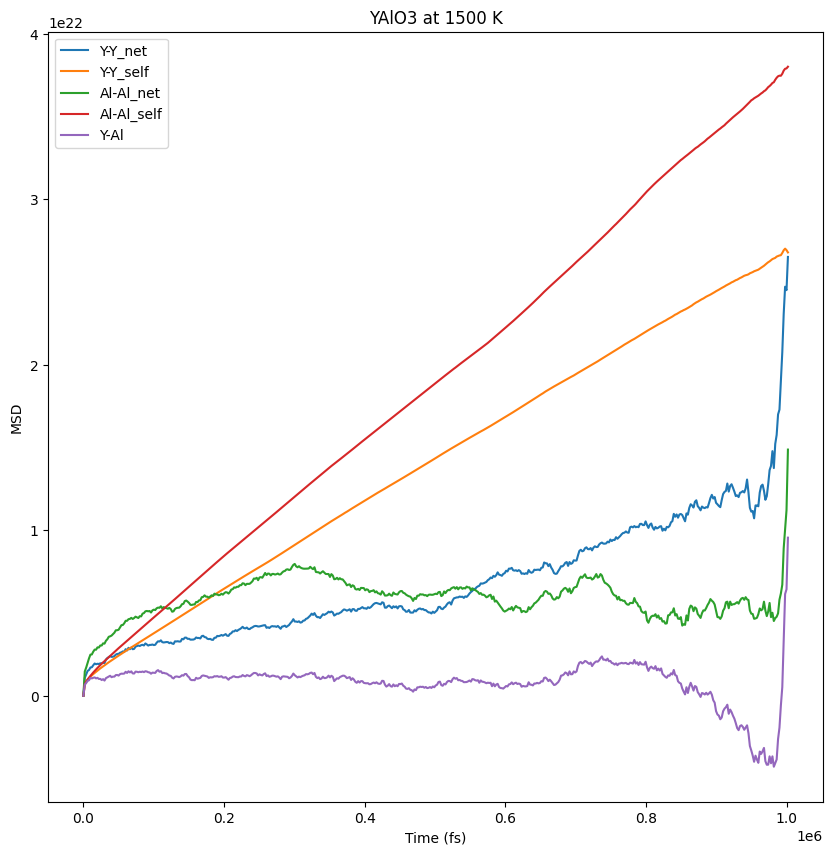

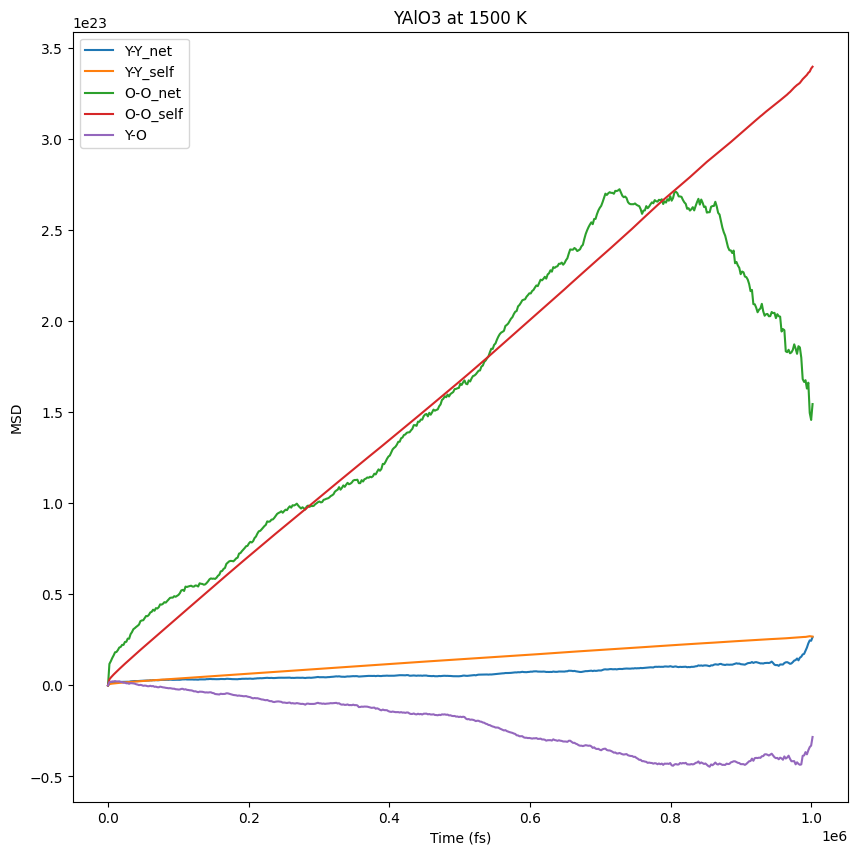

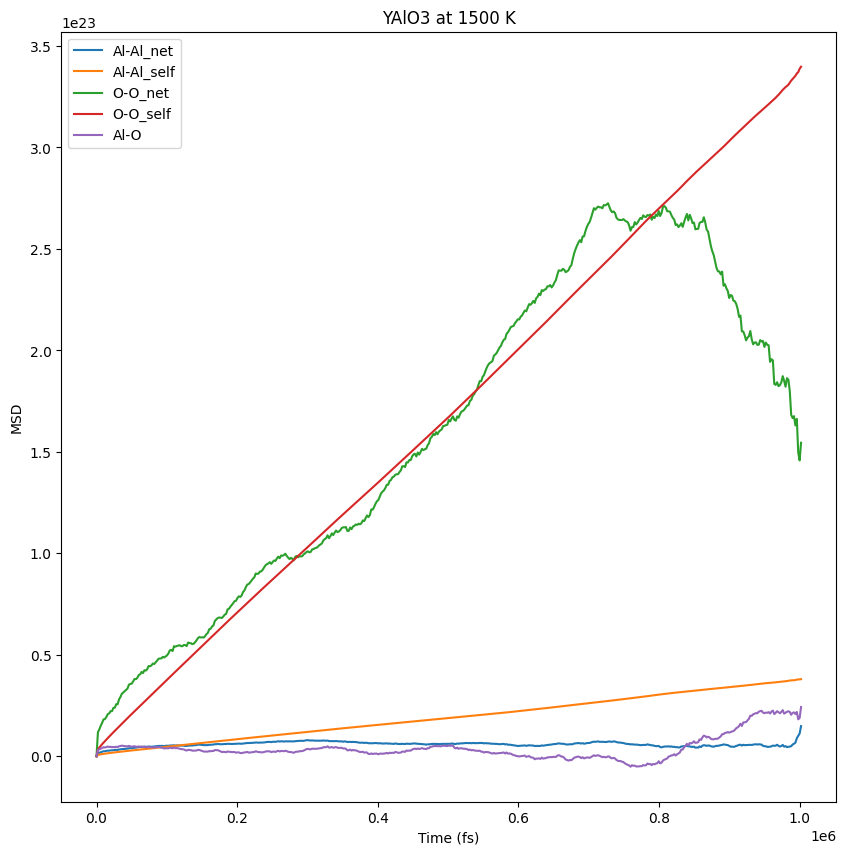

In [5]:
plot_correlation_pairwise(analyzer)

We can also plot them all in one go:

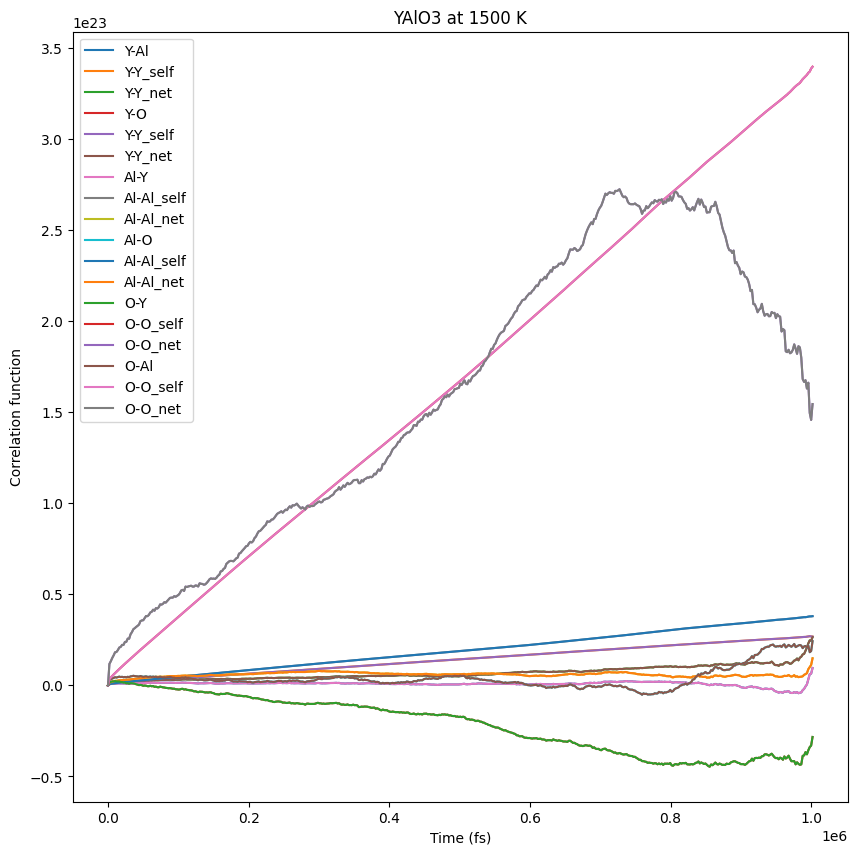

In [6]:
plot_all_correlations(analyzer)

As per the above the plot, we can trust the slopes that would be fit to the self-components for all our specie (which is great!), and the Y-Y and Al-Al net coefficients. There is often a numerical noise induced by the fourier transform in the first and last tenths of the correlation function, and so even though it looks a bit wonky for the O-O net coefficient, the slope fit should be pretty good. I would be wary of using the coefficients fit for the Y-Al, Y-O and Al-O coefficients though, and getting a longer trajectory (or bigger system) to fit these is probably a good idea. The trajectory above is only 100ps long with a size of 2700 atoms, which explains the lack of statistics for the cross-coefficients. Obviously, the code examines the quality of fits in a quantitative way and throws a warning when the fit is exceptionally poor. 

If however, you think you can eye-ball a better fit than what the code found (which BTW is totally possible, getting the fit to converge in code for any general correlation profile is hard!), you can always "refit" the coefficients as:

In [ ]:
analyzer.refit_Lij(0, 2, 100, 300) #Refit the Lij component of the transport tensor for the Y wrt O correlation using data from 20 to 60 ps